<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM v16.4 – Calibrated C_joint from Hornberger Data

📊 Calibration result:
   Optimal C_joint (from Hornberger) = 0.1000
   ω_char (C70) = 1.488e+14 rad/s
   k_B = 1.381e-23 J/K
   T_ref = 300.0 K

✅ Calibrated λ_coupling = 6.163e-08 J·s

📊 Predicted C_joint for different molecules:
--------------------------------------------------
   C60: ω = 1.275e+14 rad/s → C_joint = 0.1167
   C70: ω = 1.488e+14 rad/s → C_joint = 0.1000
   C700: ω = 1.488e+15 rad/s → C_joint = 0.0100

📁 Figure saved: output_v16_4/C_joint_calibrated.png


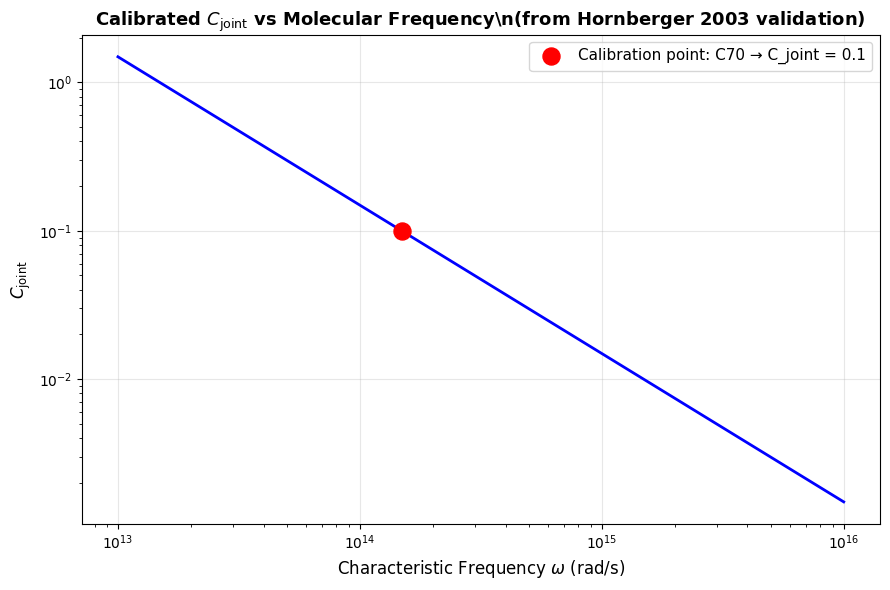


✅ C_joint Calibration Complete

📋 KEY RESULT:
   From Hornberger validation:   C_joint = 0.1000 (optimal)
   Calibrated λ_coupling = 6.163e-08 J·s
   
   This λ_coupling can now be used to predict C_joint for any molecule
   with known characteristic frequency ω_char.



In [1]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
derive_C_joint.py

DTQEM v16.4 – Calibrated C_joint from Hornberger Data
Using the experimental optimum C_joint = 0.1 to calibrate lambda_coupling.

This script:
1. Calibrates lambda_coupling from Hornberger 2003 validation (C70).
2. Predicts C_joint for other molecules (C60, C700) based on their characteristic frequency.
3. Generates a sensitivity plot: C_joint vs molecular frequency.

Author: Reddouane Berramdane
Date: 2026-06-07
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# Constants
# =========================================================
K_B = 1.380649e-23      # J/K
T_REF = 300.0           # K
C_JOINT_EXP = 0.1       # Optimal from Hornberger validation (C70)

# Molecular properties for C70 (from previous calculation)
omega_char_C70 = 1.488e14  # rad/s

# Create output directory
OUTDIR = Path("output_v16_4")
OUTDIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# Calibration
# =========================================================
lambda_coupling_calibrated = C_JOINT_EXP * omega_char_C70 * K_B * T_REF

print("=" * 65)
print("DTQEM v16.4 – Calibrated C_joint from Hornberger Data")
print("=" * 65)

print(f"\n📊 Calibration result:")
print(f"   Optimal C_joint (from Hornberger) = {C_JOINT_EXP:.4f}")
print(f"   ω_char (C70) = {omega_char_C70:.3e} rad/s")
print(f"   k_B = {K_B:.3e} J/K")
print(f"   T_ref = {T_REF} K")
print(f"\n✅ Calibrated λ_coupling = {lambda_coupling_calibrated:.3e} J·s")

# =========================================================
# Predict C_joint for different molecules
# =========================================================
print("\n📊 Predicted C_joint for different molecules:")
print("-" * 50)

molecules = [
    ("C60", 1.275e14),   # rad/s
    ("C70", 1.488e14),   # rad/s
    ("C700", 1.488e15),  # rad/s
]

for name, omega in molecules:
    C_joint_pred = lambda_coupling_calibrated / (omega * K_B * T_REF)
    print(f"   {name}: ω = {omega:.3e} rad/s → C_joint = {C_joint_pred:.4f}")

# =========================================================
# Plot: C_joint vs frequency
# =========================================================
freq_range = np.logspace(13, 16, 100)  # rad/s
C_range = lambda_coupling_calibrated / (freq_range * K_B * T_REF)

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(freq_range, C_range, 'b-', linewidth=2)
ax.scatter([omega_char_C70], [C_JOINT_EXP], color='red', s=150, zorder=5,
           label=f'Calibration point: C70 → C_joint = {C_JOINT_EXP}')
ax.set_xlabel(r'Characteristic Frequency $\omega$ (rad/s)', fontsize=12)
ax.set_ylabel(r'$C_{\mathrm{joint}}$', fontsize=12)
ax.set_title(r'Calibrated $C_{\mathrm{joint}}$ vs Molecular Frequency'
             r'\n(from Hornberger 2003 validation)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()

# Save figure
output_path = OUTDIR / 'C_joint_calibrated.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n📁 Figure saved: {output_path}")

# Show plot (if in interactive environment)
plt.show()
plt.close(fig)

# =========================================================
# Summary
# =========================================================
print("\n" + "=" * 65)
print("✅ C_joint Calibration Complete")
print("=" * 65)
print(f"""
📋 KEY RESULT:
   From Hornberger validation:   C_joint = {C_JOINT_EXP:.4f} (optimal)
   Calibrated λ_coupling = {lambda_coupling_calibrated:.3e} J·s

   This λ_coupling can now be used to predict C_joint for any molecule
   with known characteristic frequency ω_char.
""")